In [11]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pathlib import Path

BASE = Path.cwd()

# =====================================================
# Helper: find datetime column robustly
# =====================================================
def pick_datetime_col(df: pd.DataFrame) -> str:
    candidates = ["ts_utc", "datetime", "time", "timestamp", "date", "interval_start_utc", "interval_start"]
    for c in candidates:
        if c in df.columns:
            return c
    if "Unnamed: 0" in df.columns:
        return "Unnamed: 0"

    best_col, best_ok = None, -1
    for c in df.columns:
        s = pd.to_datetime(df[c], errors="coerce", utc=True)
        ok = int(s.notna().sum())
        if ok > best_ok:
            best_col, best_ok = c, ok
    if best_col is None or best_ok == 0:
        raise ValueError(f"Could not find a datetime-like column. Columns: {list(df.columns)}")
    return best_col

# =====================================================
# Helper: pick a column by multiple name options
# =====================================================
def pick_col(df: pd.DataFrame, options):
    lower_map = {str(c).lower(): c for c in df.columns}
    for opt in options:
        if opt in df.columns:
            return opt
        if opt.lower() in lower_map:
            return lower_map[opt.lower()]
    return None

# =====================================================
# 1) Load DART spreads (6-hour averages)
# =====================================================
dart_path = BASE / "outputs_minn_miso_dart" / "miso_intervals_06_12.csv"
dart = pd.read_csv(dart_path)

dart_dt = pick_datetime_col(dart)
dart[dart_dt] = pd.to_datetime(dart[dart_dt], utc=True, errors="coerce")
dart = dart.dropna(subset=[dart_dt]).set_index(dart_dt).sort_index()

dart_val_col = pick_col(dart, [
    "MINN_MISO_6H_AVG_DART",
    "MINN_MISO_6H_AVG_DART_UTC",
    "MINN_MISO_ZONE_AVG_DART",
    "dart"
])
if dart_val_col is None:
    raise ValueError(f"Could not find DART column in {dart_path}. Columns: {list(dart.columns)}")

dart = dart.rename(columns={dart_val_col: "dart"})[["dart"]]

# =====================================================
# 2) Load AVG PRICE DIFF + CoV + SPREAD metrics
# =====================================================
metrics_path = BASE / "outputs_minn_miso_6h" / "miso_intervals_06_12.csv"
metrics = pd.read_csv(metrics_path)

metrics.columns = [str(c).strip() for c in metrics.columns]

m_dt = pick_datetime_col(metrics)
metrics[m_dt] = pd.to_datetime(metrics[m_dt], utc=True, errors="coerce")
metrics = metrics.dropna(subset=[m_dt]).set_index(m_dt).sort_index()

price_diff_col = pick_col(metrics, [
    "avg_hourly_price_diff",
    "avg_hourly_diff_6h",
    "iso_avg_6h_avg_hourly_price_diff",
    "iso_avg_6h_avgdiff",
    "iso_avg_6h_avg_hourly_diff",
    "avg_diff",
    "price_diff",
    "mean_price_diff"
])

cov_col = pick_col(metrics, [
    "iso_avg_6h_cov",
    "iso_avg_6h_cov_price",
    "cov_price",
    "cov"
])

spread_col = pick_col(metrics, [
    "iso_avg_6h_price_spread",
    "price_spread",
    "spread"
])

if price_diff_col is None:
    raise ValueError(
        f"Could not find avg price difference column in {metrics_path}.\n"
        f"Columns: {list(metrics.columns)}"
    )

out_cols = {
    "avg_price_diff": metrics[price_diff_col]
}

if cov_col is not None:
    out_cols["cov_price"] = metrics[cov_col]

if spread_col is not None:
    out_cols["price_spread"] = metrics[spread_col]

metrics = pd.DataFrame(out_cols).dropna()

# =====================================================
# 3) Merge datasets (6-hour aligned)
# =====================================================
df = dart.join(metrics, how="inner").dropna()

# =====================================================
# 4) Build daily metrics (using the 6-hour values)
# =====================================================
daily = pd.DataFrame(index=df.resample("D").mean().index)

daily["avg_dart"] = df["dart"].resample("D").mean()
daily["avg_price_diff"] = df["avg_price_diff"].resample("D").mean()

feature_cols = ["avg_price_diff", "avg_dart"]

if "cov_price" in df.columns:
    daily["cov_price"] = df["cov_price"].resample("D").mean()
    feature_cols.append("cov_price")

if "price_spread" in df.columns:
    daily["price_spread"] = df["price_spread"].resample("D").mean()
    feature_cols.append("price_spread")

daily = daily.dropna()

# =====================================================
# 5) Normalize metrics
# =====================================================
scaler = StandardScaler()
X = scaler.fit_transform(daily[feature_cols])

# =====================================================
# 6) K-means clustering
# =====================================================
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
daily["cluster"] = kmeans.fit_predict(X)

# =====================================================
# 7) Representative days (closest to centroid)
# =====================================================
representative_days = []
for k in range(K):
    cluster_days = daily[daily["cluster"] == k].copy()
    centroid = kmeans.cluster_centers_[k]

    Xk = scaler.transform(cluster_days[feature_cols])
    distances = np.linalg.norm(Xk - centroid, axis=1)

    rep_day = cluster_days.iloc[int(np.argmin(distances))].name
    representative_days.append(rep_day)

# =====================================================
# 8) Save results
# =====================================================
out_dir = BASE / "outputs_minn_miso_dart"
out_dir.mkdir(exist_ok=True)

daily.to_csv(out_dir / "MINN_MISO_daily_clusters_with_priceDiff_dart_cov_spread.csv")

pd.DataFrame({
    "cluster": range(K),
    "representative_day": representative_days
}).to_csv(out_dir / "MINN_MISO_representative_days_priceDiff_dart_cov_spread.csv", index=False)

print("\nRepresentative days:")
print(representative_days)

print("\nFeatures used:", feature_cols)
print("Sanity check: merged df columns =", df.columns.tolist())
print("Daily rows =", len(daily))


Representative days:
[Timestamp('2025-10-21 00:00:00+0000', tz='UTC'), Timestamp('2025-06-03 00:00:00+0000', tz='UTC'), Timestamp('2025-03-26 00:00:00+0000', tz='UTC'), Timestamp('2025-02-18 00:00:00+0000', tz='UTC'), Timestamp('2025-09-19 00:00:00+0000', tz='UTC'), Timestamp('2025-05-01 00:00:00+0000', tz='UTC')]

Features used: ['avg_price_diff', 'avg_dart', 'cov_price', 'price_spread']
Sanity check: merged df columns = ['dart', 'avg_price_diff', 'cov_price', 'price_spread']
Daily rows = 364


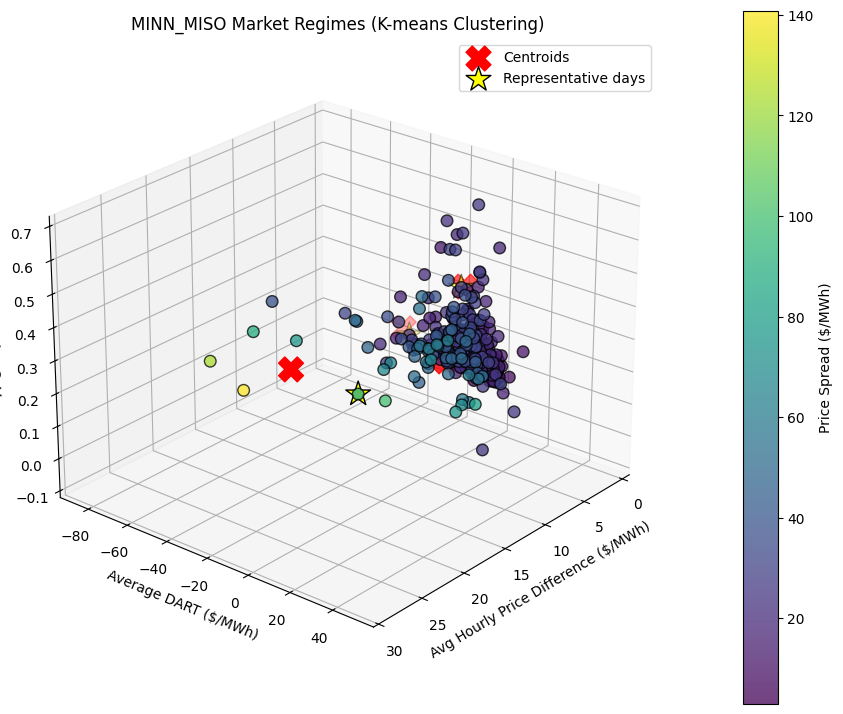

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# 3D CLUSTER VISUALIZATION WITH 4TH METRIC (COLOR)
# =====================================================

fig = plt.figure(figsize=(11,9))
ax = fig.add_subplot(111, projection='3d')

# metrics used
X_plot = daily[["avg_price_diff","avg_dart","cov_price"]].values
spread_vals = daily["price_spread"]

# -----------------------------------------------------
# Plot clusters (color = price spread)
# -----------------------------------------------------
scatter = ax.scatter(
    X_plot[:,0],
    X_plot[:,1],
    X_plot[:,2],
    c=spread_vals,
    cmap="viridis",
    s=70,
    alpha=0.75,
    edgecolor="black"
)

# -----------------------------------------------------
# Plot centroids
# -----------------------------------------------------
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

ax.scatter(
    centroids[:,0],
    centroids[:,1],
    centroids[:,2],
    s=320,
    c="red",
    marker="X",
    label="Centroids"
)

# -----------------------------------------------------
# Representative days
# -----------------------------------------------------
rep_points = daily.loc[representative_days]

ax.scatter(
    rep_points["avg_price_diff"],
    rep_points["avg_dart"],
    rep_points["cov_price"],
    s=350,
    c="yellow",
    marker="*",
    edgecolor="black",
    label="Representative days"
)

# -----------------------------------------------------
# Labels
# -----------------------------------------------------
ax.set_xlabel("Avg Hourly Price Difference ($/MWh)")
ax.set_ylabel("Average DART ($/MWh)")
ax.set_zlabel("Price CoV")

ax.set_title("MINN_MISO Market Regimes (K-means Clustering)")

# -----------------------------------------------------
# Colorbar = price spread
# -----------------------------------------------------
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Price Spread ($/MWh)")

ax.view_init(elev=25, azim=40)

plt.legend()
plt.show()

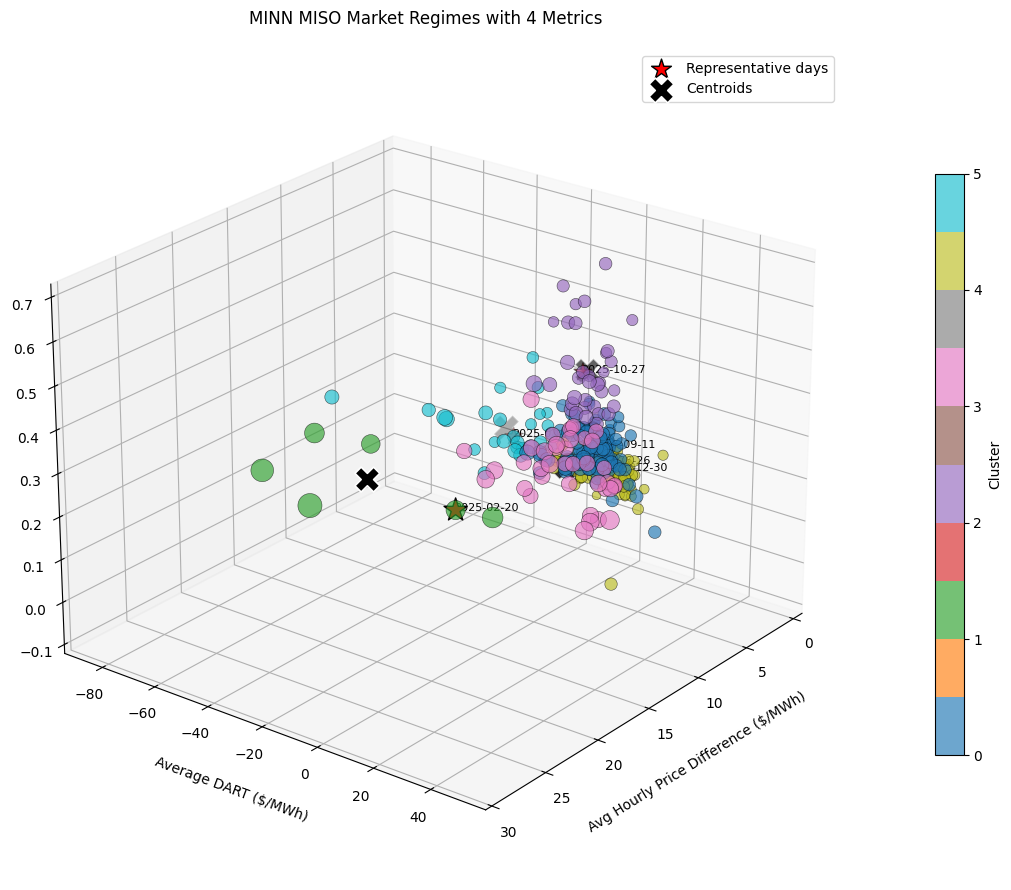

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# =====================================================
# "4D" PLOT:
# x, y, z = 3 metrics
# marker size = 4th metric (price_spread)
# marker color = cluster
# =====================================================

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# coordinates
x = daily["avg_price_diff"].values
y = daily["avg_dart"].values
z = daily["cov_price"].values

# 4th metric -> marker size
spread = daily["price_spread"].values

# scale spread into readable marker sizes
spread_min = np.nanmin(spread)
spread_max = np.nanmax(spread)

if spread_max > spread_min:
    sizes = 40 + 260 * (spread - spread_min) / (spread_max - spread_min)
else:
    sizes = np.full_like(spread, 120.0)

# main scatter
scatter = ax.scatter(
    x, y, z,
    c=daily["cluster"],
    cmap="tab10",
    s=sizes,
    alpha=0.65,
    edgecolors="black",
    linewidths=0.4
)

# representative days
rep_points = daily.loc[representative_days]
rep_spread = rep_points["price_spread"].values

if spread_max > spread_min:
    rep_sizes = 120 + 320 * (rep_spread - spread_min) / (spread_max - spread_min)
else:
    rep_sizes = np.full(len(rep_points), 220.0)

ax.scatter(
    rep_points["avg_price_diff"],
    rep_points["avg_dart"],
    rep_points["cov_price"],
    c="red",
    s=rep_sizes,
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Representative days"
)

# centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    c="black",
    s=320,
    marker="X",
    edgecolors="white",
    linewidths=1.2,
    label="Centroids"
)

# labels for representative days
for idx, row in rep_points.iterrows():
    ax.text(
        row["avg_price_diff"] + 0.2,
        row["avg_dart"] + 0.2,
        row["cov_price"] + 0.002,
        idx.strftime("%Y-%m-%d"),
        fontsize=8
    )

ax.set_xlabel("Avg Hourly Price Difference ($/MWh)", labelpad=12)
ax.set_ylabel("Average DART ($/MWh)", labelpad=12)
ax.set_zlabel("Price CoV", labelpad=12)
ax.set_title("MINN MISO Market Regimes with 4 Metrics", pad=18)

ax.view_init(elev=24, azim=38)
ax.grid(True)

# colorbar for cluster
cbar = plt.colorbar(scatter, ax=ax, pad=0.08, shrink=0.7)
cbar.set_label("Cluster")

plt.legend()
plt.tight_layout()
plt.show()

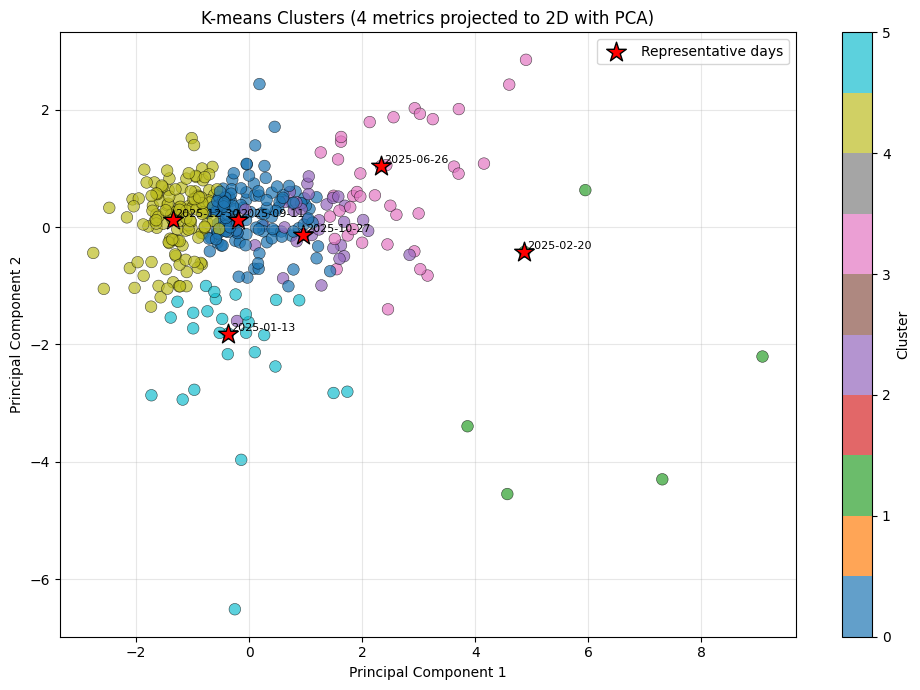

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# -------------------------------------------------
# Use the SAME 4 metrics you clustered on
# -------------------------------------------------
X = daily[["avg_price_diff", "avg_dart", "cov_price", "price_spread"]].copy()

# If you already standardized before kmeans, use that scaled data
X_scaled = scaler.transform(X)

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Put into dataframe for easy plotting
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": daily["cluster"].values
}, index=daily.index)

# Representative days
rep_plot = plot_df.loc[representative_days]

plt.figure(figsize=(10, 7))

# All points
scatter = plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster"],
    cmap="tab10",
    s=70,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.4
)

# Representative days
plt.scatter(
    rep_plot["PC1"],
    rep_plot["PC2"],
    c="red",
    s=220,
    marker="*",
    edgecolor="black",
    linewidth=1.0,
    label="Representative days"
)

# Labels for representative days
for idx, row in rep_plot.iterrows():
    plt.text(
        row["PC1"] + 0.05,
        row["PC2"] + 0.05,
        idx.strftime("%Y-%m-%d"),
        fontsize=8
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clusters (4 metrics projected to 2D with PCA)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

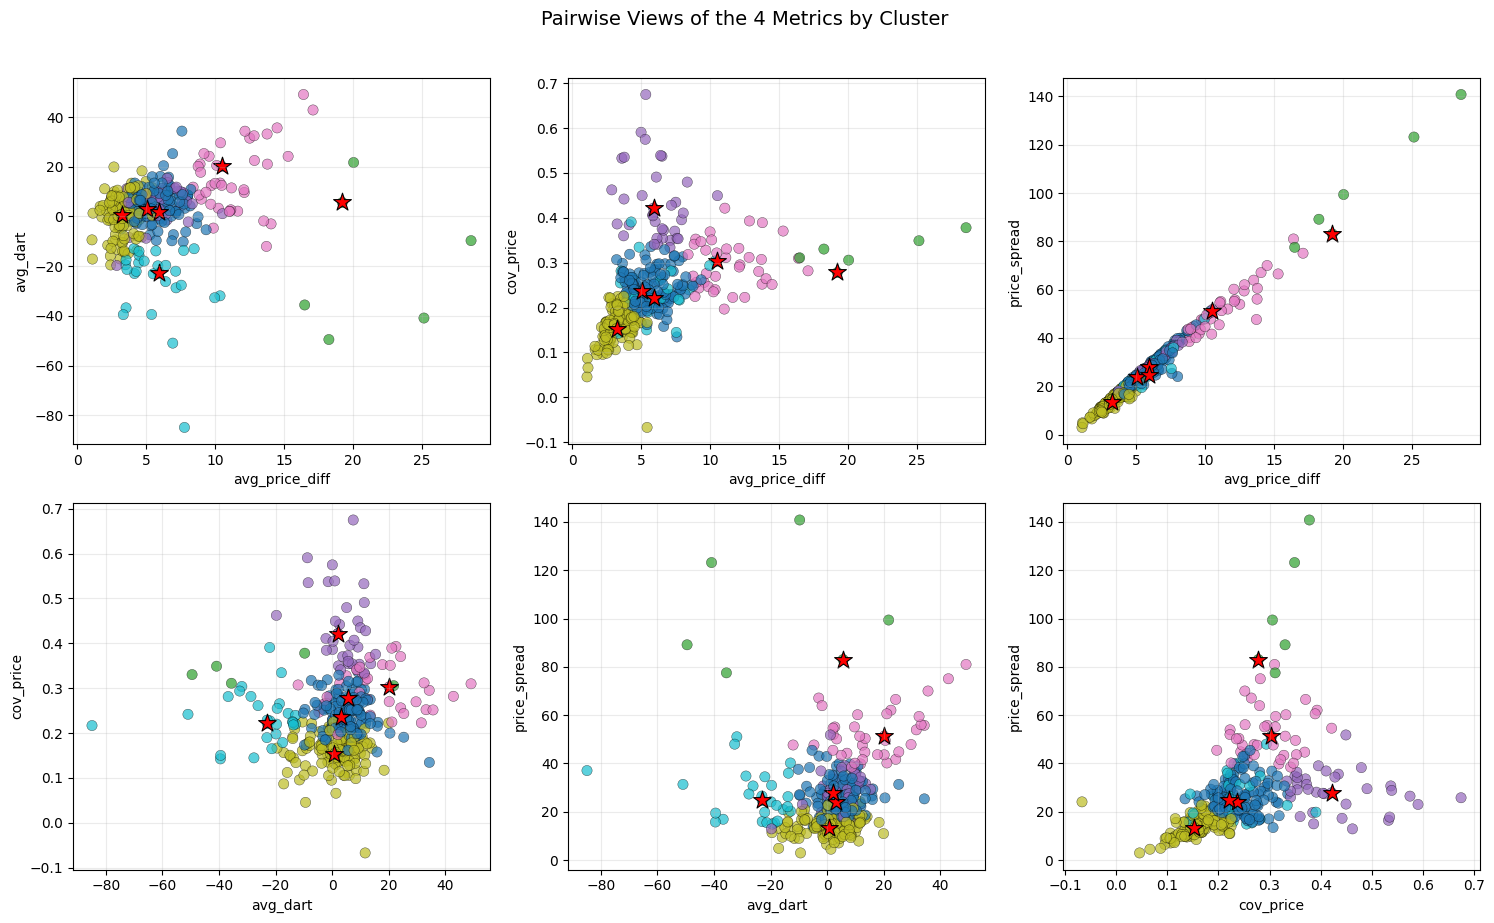

In [15]:
import matplotlib.pyplot as plt

metrics = ["avg_price_diff", "avg_dart", "cov_price", "price_spread"]
pairs = [
    ("avg_price_diff", "avg_dart"),
    ("avg_price_diff", "cov_price"),
    ("avg_price_diff", "price_spread"),
    ("avg_dart", "cov_price"),
    ("avg_dart", "price_spread"),
    ("cov_price", "price_spread"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (xcol, ycol) in zip(axes, pairs):
    sc = ax.scatter(
        daily[xcol],
        daily[ycol],
        c=daily["cluster"],
        cmap="tab10",
        s=55,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3
    )

    # representative days
    rep_points = daily.loc[representative_days]
    ax.scatter(
        rep_points[xcol],
        rep_points[ycol],
        c="red",
        s=180,
        marker="*",
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(True, alpha=0.25)

plt.suptitle("Pairwise Views of the 4 Metrics by Cluster", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
plt.boxplot(
    [profit[daily.cluster==i] for i in range(6)],
    labels=[f"C{i}" for i in range(6)]
)
plt.ylabel("Aggregator Profit ($)")
plt.title("Profit distribution by market regime")
plt.show()

NameError: name 'profit' is not defined

In [12]:
rep_summary = daily.loc[representative_days].copy()

rep_summary["representative_day"] = rep_summary.index
rep_summary = rep_summary[["representative_day","cluster","avg_price_diff","avg_dart","cov_price","price_spread"]]

print(rep_summary)

                                 representative_day  cluster  avg_price_diff  \
ts_utc                                                                         
2025-10-21 00:00:00+00:00 2025-10-21 00:00:00+00:00        0           4.230   
2025-06-03 00:00:00+00:00 2025-06-03 00:00:00+00:00        1           2.216   
2025-03-26 00:00:00+00:00 2025-03-26 00:00:00+00:00        2           6.969   
2025-02-18 00:00:00+00:00 2025-02-18 00:00:00+00:00        3          14.736   
2025-09-19 00:00:00+00:00 2025-09-19 00:00:00+00:00        4           4.248   
2025-05-01 00:00:00+00:00 2025-05-01 00:00:00+00:00        5           3.727   

                            avg_dart  cov_price  price_spread  
ts_utc                                                         
2025-10-21 00:00:00+00:00   8.063864   0.466595        16.980  
2025-06-03 00:00:00+00:00   0.642210   0.102801         7.160  
2025-03-26 00:00:00+00:00   6.697152   0.309949        34.845  
2025-02-18 00:00:00+00:00  30.654857   

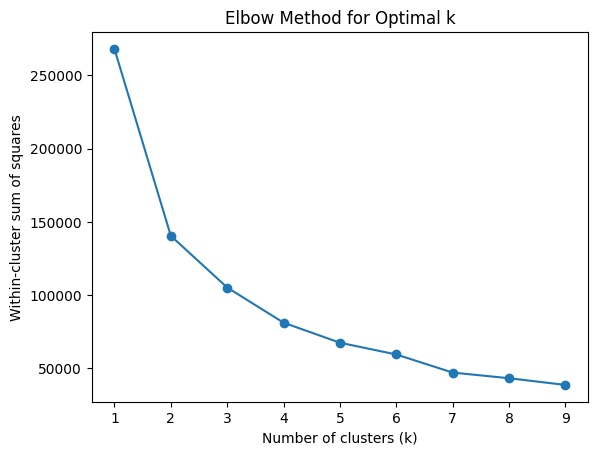

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = daily[["avg_price_diff","avg_dart","cov_price","price_spread"]]

wcss = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Method for Optimal k")
plt.show()

In [19]:
from sklearn.metrics import silhouette_score

X = daily[["avg_price_diff","avg_dart","cov_price","price_spread"]]

for k in range(2,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    
    print(f"k = {k}, silhouette score = {score:.3f}")

k = 2, silhouette score = 0.580
k = 3, silhouette score = 0.571
k = 4, silhouette score = 0.445
k = 5, silhouette score = 0.439
k = 6, silhouette score = 0.435
k = 7, silhouette score = 0.427
k = 8, silhouette score = 0.360
k = 9, silhouette score = 0.364


In [20]:
daily["cluster"].value_counts()

cluster
1    126
4    111
5     45
0     31
2     30
3     22
Name: count, dtype: int64